**Aula 04 – Regressão Linear**

_Notebook de Demonstração de Regressão Linear._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

O projeto requer Python 3.7 ou acima:

In [1]:
import sys

assert sys.version_info >= (3, 7)

Também requer Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Definindo as fontes dos gráficos, apenas para estética:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Define a função `save_fig()`, que gravará as imagens geradas para os gráficos na pasta `images/training_linear_models`. Assim todas as imagens plotadas abaixo, ficam disponíveis para download.

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Regressão Linear

## A Equação Normal

O Código abaixo gera um DataSet com 100 linhas, e valores aleatórios, apenas para exemplificar a Regressão Linear.

In [5]:
import numpy as np

np.random.seed(42)  # seed, pra que todos tenham o mesmo conjunto de dados
m = 100  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector

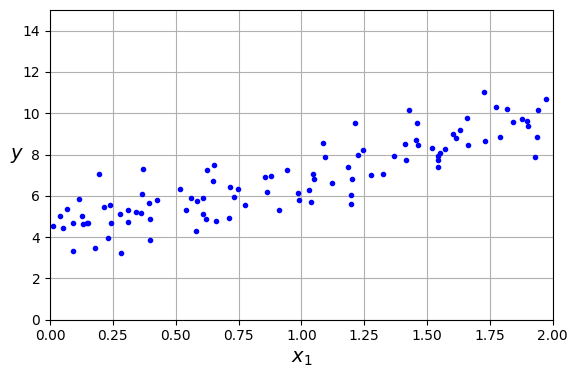

In [6]:
# Representação Visual do Conjunto de Dados

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

Aqui vamos aplicar a **Equação Normal** para identificar o θ0 e θ1

In [7]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [8]:
theta_best

array([[4.21509616],
       [2.77011339]])

Aqui faremos predições com o θ calculado

In [9]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

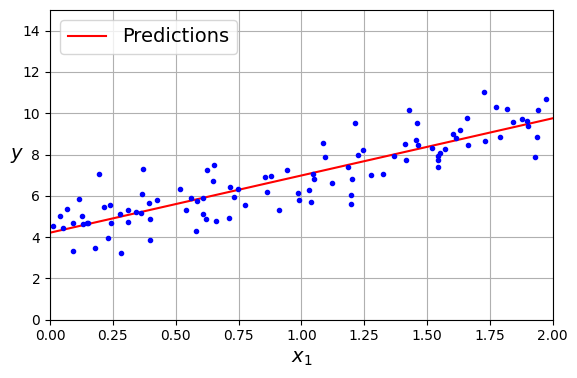

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

Abaixo, vamos executar a Regressão Linear usando o Scikit Learn, que é bem mais simples.

In [11]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [12]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

A classe LinearRegression é baseada na função `scipy.linalg.lstsq()` (o nome significa “mínimos quadrados”), que você poderia chamar diretamente:

In [13]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

Essa função calcula $\mathbf{X}^+\mathbf{y}$, onde $\mathbf{X}^{+}$ é a pseudoinversa de $\mathbf{X}$ (especificamente a inversa de Moore–Penrose).

Você pode usar np.linalg.pinv() para calcular a pseudoinversa diretamente:

In [14]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

Agora veremos como aplicar a fórmula da MSE para calcular o erro global.

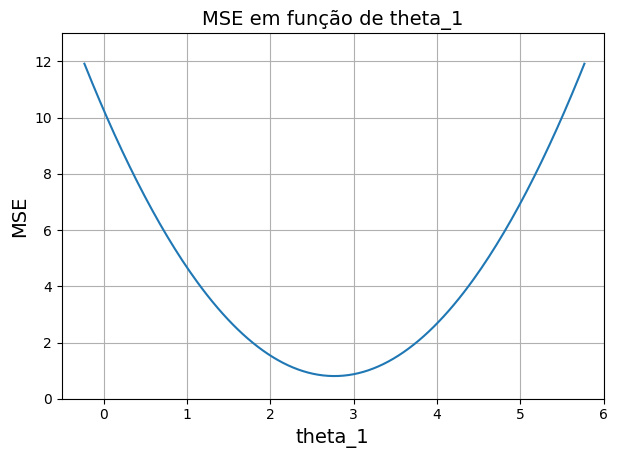

In [15]:
from sklearn.metrics import mean_squared_error

theta_0 = lin_reg.intercept_[0]
theta_1_opt = lin_reg.coef_[0][0]

theta_1_values = np.linspace(theta_1_opt - 3, theta_1_opt + 3, 200)
mse_values = []

for t1 in theta_1_values:
    y_pred = theta_0 + t1 * X
    mse = mean_squared_error(y, y_pred)
    mse_values.append(mse)

plt.figure()
plt.plot(theta_1_values, mse_values)
plt.xlabel("theta_1")
plt.ylabel("MSE")
plt.axis([-0.5, 6, 0, 13])
plt.grid()
plt.title("MSE em função de theta_1")
save_fig("linear_model_mse_bowl")
plt.show()

### FIM DA 1ª DA DEMONSTRAÇÃO - voltar aos slides

# Gradiente Descendente

Gradient Descent é um método para encontrar o menor erro possível ajustando os valores de θ passo a passo.

## Gradiente Descendente em Batch

Aqui temos o código para calculo do θ utilizando o algoritmo do Gradiente Descendente em Batch

In [16]:
eta = 0.1  # Taxa de Aprendizado
n_epochs = 1000
m = len(X_b)  # Quantidade de Instâncias

np.random.seed(42)
theta = np.random.randn(2, 1)  # Modelo de Parametros inicializado randomicamente

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

The trained model parameters:

In [17]:
theta

array([[4.21509616],
       [2.77011339]])

Abaixo é o código que gera 3 imagens, mostrando as 20 primeiras etapas do Gradiente Descendente usando Taxas de Aprendizado (η → eta) diferentes.

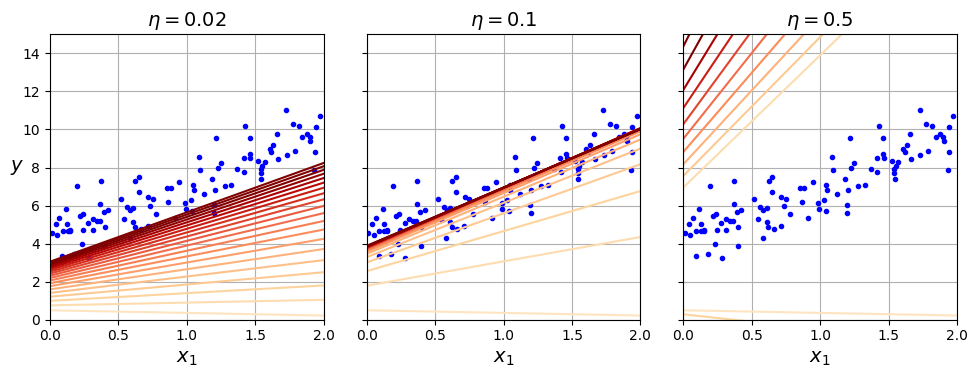

In [18]:
import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

## Gradiente Descendente Estocástico

In [19]:
theta_path_sgd = []  # Armazenando o caminho do Theta para exibir na figura

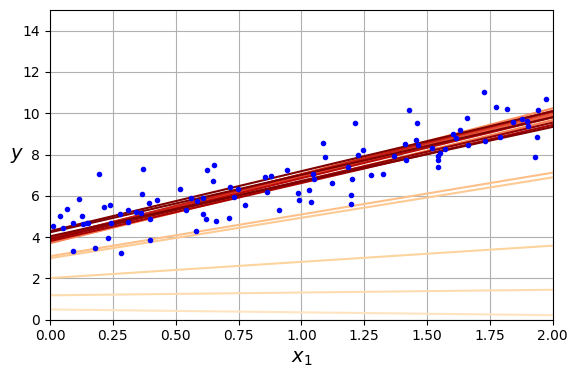

In [20]:
n_epochs = 50
t0, t1 = 5, 50  # hiperparametros do cronograma de aprendizado

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # inicialização randômica

n_shown = 20  # quantidade de etapas a serem exibidas na figura
plt.figure(figsize=(6, 4))

for epoch in range(n_epochs):
    for iteration in range(m):

        # código – estas 4 linhas são usadas para gerar a figura do gráfico
        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # para SGD, não dividir por m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

# Formatando e exibindo a figura do gráfico
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("sgd_plot")
plt.show()

In [21]:
theta

array([[4.21076011],
       [2.74856079]])

In [22]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets


SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [23]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

## Gradiente descendente em minibatch

O Gradiente Descendente em Minibatch é exatamente o “meio-termo inteligente” entre o Gradiente Descendente em Batch e o Gradiente Descendente Estocástico.

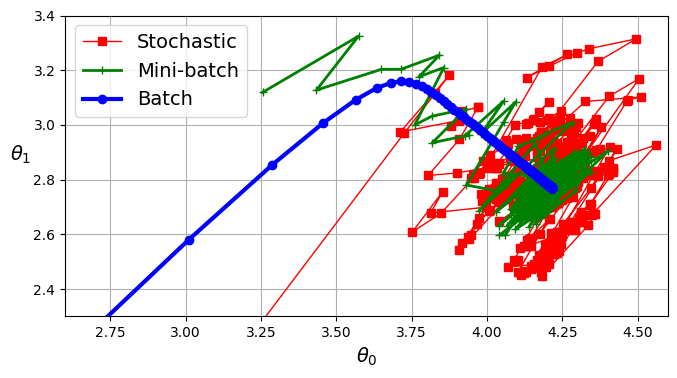

In [24]:
# extra code – this cell generates and saves Figure 4–11

from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

t0, t1 = 200, 1000  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.6, 4.6, 2.3, 3.4])
plt.grid()
save_fig("gradient_descent_paths_plot")
plt.show()

**INFORMAÇÕES IMPORTANTES**
**Gradiente Descendente e Scikit-Learn**

O scikit-learn NÃO expõe explicitamente três algoritmos separados chamados:
- Batch Gradient Descent
- Stochastic Gradient Descent
- Mini-batch Gradient Descent

👉 Ele expõe estimadores, e o tipo de gradiente é um detalhe interno.

Abaixo, há uma equivalência "prática" de cada método usando o Scikit-Learn, sem implementar os cálculos de álgebra linear diretamente no código.


---



**1️⃣ Batch Gradient Descent (BGD)**

👉 Não existe um estimador que implemente Batch Gradient Descent puro. Por quê?
- Não escala bem
- Não é usado em produção
- A solução analítica é melhor quando possível

No exemplo abaixo:
- Não usa Gradient Descent
- Resolve o mesmo problema que o Batch GD
- Encontra o mínimo exato do MSE

In [25]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

**2️⃣ Stochastic Gradient Descent (SGD)**

✅ Implementação oficial no scikit-learn

A classe SGDRegressor implementa oficialmente o Gradiente Descendente Estocástico, porém, nas versões mais recentes passou a utilizar o Gradiente Descendente em Minibatch.

O parâmetro learning-rate permite indicar que a taxa de aprendizado deve ser sempre a mesma, emulando melhor o comportamento do Gradiente Desendente Estocástico.


In [26]:
sgd_lin_reg = SGDRegressor(
    learning_rate="constant",
    max_iter=1000,
    tol=1e-5,
    penalty=None,
    eta0=0.01,
    n_iter_no_change=100,
    random_state=42
)

sgd_lin_reg.fit(X, y.ravel())
sgd_lin_reg.intercept_, sgd_lin_reg.coef_

(array([4.21721358]), array([2.77967544]))

**3️⃣ Gradiente Descendente em Minibatch**

⚠️ Aqui está a sutileza

👉 O scikit-learn não permite configurar explicitamente o batch size no SGDRegressor, mas:

    Internamente, ele usa mini-batches otimizados, especialmente em versões recentes.

Ou seja:
- Você usa o mesmo SGDRegressor
- O mini-batch é um detalhe interno da implementação
- Nas versões mais recentes, o Scikit-Learn já faz a divisão dos dados em Lotes, aplicando o algoritmo de Gradiente Descendente em Minibactch

✅ Implementação prática (Mini-batch implícito)

In [27]:
sgm_lin_reg = SGDRegressor(
    learning_rate="invscaling", # Na versão utilizada, invscaling é o valor padrão deste parâmetro
    max_iter=1000,
    tol=1e-5,
    penalty=None,
    eta0=0.02,
    n_iter_no_change=100,
    random_state=42
)

sgm_lin_reg.fit(X, y.ravel())
sgm_lin_reg.intercept_, sgm_lin_reg.coef_

(array([4.21533911]), array([2.7706979]))

### FIM DA 2ª DA DEMONSTRAÇÃO - voltar aos slides

# Regressão Polinomial

E se os dados forem mais complexos que uma linha reta? Há situações em que se pode usar um modelo linear para ajustar modelos não lineares.

Abaixo será gerado um conjunto de dados usando uma função quadrática simples:

$\mathbf{y}={ax}^2+{bx}+{c}$

In [28]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

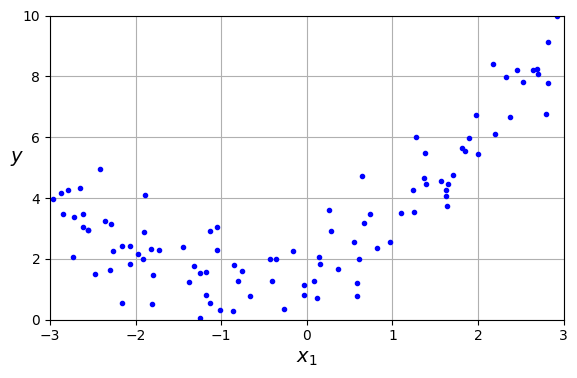

In [29]:
# Exibindo o Conjunto de dados gerados
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_data_plot")
plt.show()

Vamos adicionar uma nova característica, que será o quadrado de cada um dos valores de X, e criar um novo dataset em X_poly.

In [30]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [31]:
X_poly[0]

array([-0.75275929,  0.56664654])

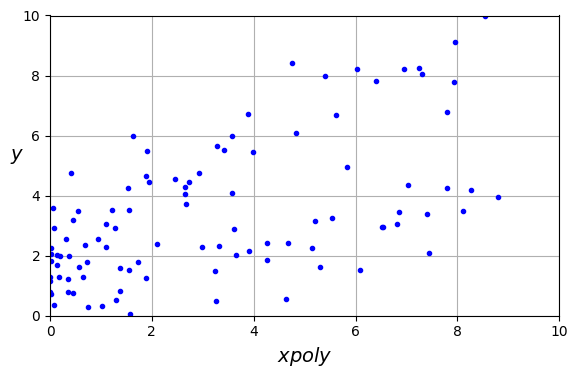

In [32]:
# Exibindo o Conjunto de dados gerados para o Quadrado de X
plt.figure(figsize=(6, 4))
plt.plot(X_poly[:,1], y, "b.")
plt.xlabel("$xpoly$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 10, 0, 10])
plt.grid()
save_fig("polimonial_data_plot")
plt.show()

A partir do conjunto de dados X_poly, podemos treinar um modelo de Regressão Linear.

In [33]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

Observe a função original do cálculo, e o que o modelo estimou:

- Original → $\mathbf{y}={0.5x}^2+{1.0x}+{2}+$"ruído gaussiano"

- Estimado → $\mathbf{y}={0.56x}^2+{0.93x}+{1.78}$

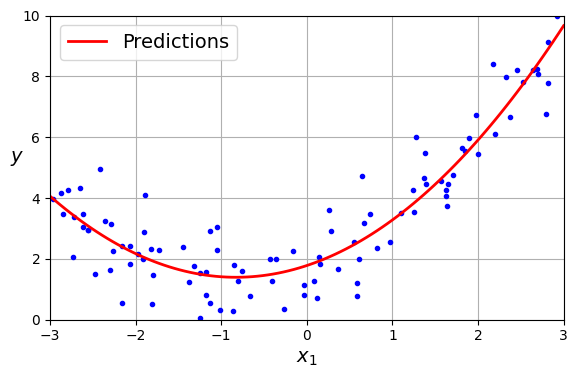

In [34]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_predictions_plot")
plt.show()

# Curvas de Aprendizado

Aqui temos um gráfico que compara as Linhas do treino, entre uma Regressão Linear Simples (já observado), com um ajuste de 2 Grau (já observado), e um ajuste de 300 Grau.

Observe que na linha de 300 grau, há claramente um sobreajuste aos dados. Para a nossa função, é simples identificar que um ajuste de 2 grau é o mais adequado, pois conhecemos a função que gerou os dados.

Em geral, não temos esta informação.

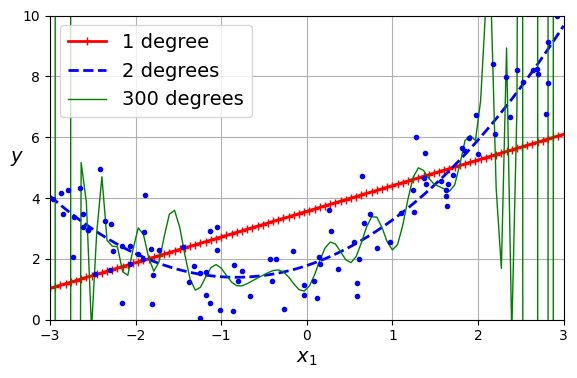

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(6, 4))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("high_degree_polynomials_plot")
plt.show()

O Scikit Learn tem uma função bem útil, a `learning_curve()`, ela treina e avalia o modelo utilizando validação cruzada e um modelo de Regressão Linear simples.

Na linha azul temos a medida do erro (RMSE) ao fazer predições nos dados de Validação, e na linha azul, temos o erro ao fazer predições nos dados de Treino.

As linhas convergem rapidamente para um grau auto de erro, e permanece constante, mesmo adicionando mais dados ao treinamento. Isso demonstra claramente que há um subajuste dos dados ao modelo, indicando que o problema não é a falta de dados, e sim a incapacidade do modelo de lidar com os dados.

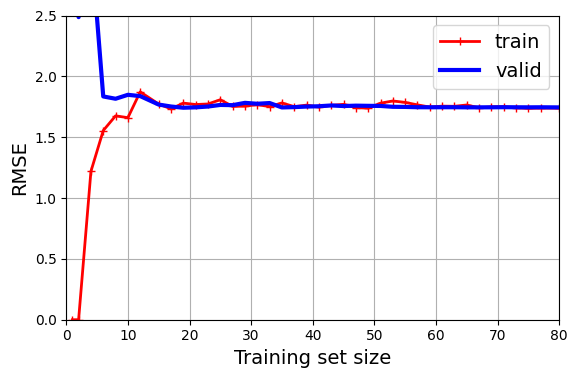

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
save_fig("underfitting_learning_curves_plot")

plt.show()

**Curva de Aprendizado com Regressão Polinomial de Grau 2**

In [ ]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

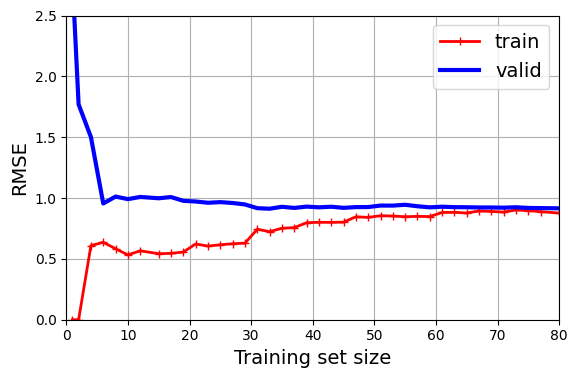

In [ ]:
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
save_fig("learning_curves_plot")
plt.show()

**Curva de Aprendizado com Regressão Polinomial de Grau 10**

In [ ]:
from sklearn.pipeline import make_pipeline

polynomial_regression10 = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression10, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

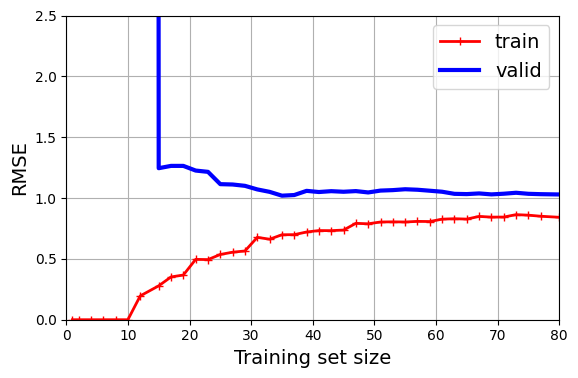

In [ ]:
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
save_fig("learning_curves_plot")
plt.show()

### FIM DA 3ª DA DEMONSTRAÇÃO - voltar aos slides

# Modelos Lineares Regularizados

## Regressão Ridge (L2)

É um modelo de regularização, que penaliza coeficientes grandes, adicionando um termo de regularização ao erro do modelo.

Na fórmula original da Regressão Linear, coeficientes são os Thetas ($\theta$) das características. Este método de regularização procura minimizar o valor dos valores $\theta_1$, $\theta_2$ até o $\theta_n$ da função, sem zerar nenhum deles.

---

**Para demonstrar**

Vamos gerar um pequeno dataset linear com ruído:

In [ ]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

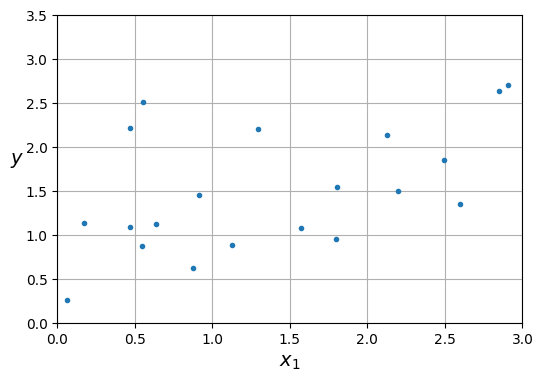

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

No Gráfico gerado, temos a comparação entre Modelos Lineares comuns e Modelos Regularizados através da função `PolynomialFeatures(degree=10)` com diversos valores para α (alpha).

Repare que, o almento do α leva a predições mais planas, reduzindo a variância do modelo, mas aumentando o seu viés. Já um α menor, leva a um claro overfitting do modelo.

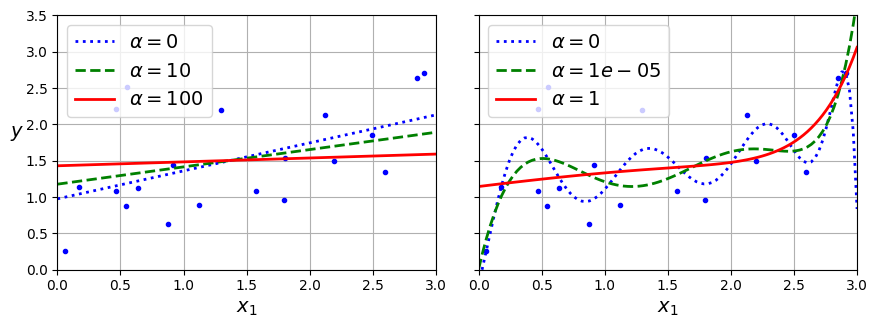

In [ ]:
from sklearn.linear_model import Ridge

def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
save_fig("ridge_regression_plot")
plt.show()

Abaixo, será treinado um Modelo de Regressão Linear utilizando o regularização L2 (Ridge), e fazendo a Predição y, para o X 1.5

In [ ]:
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55325833])

Agora temos um Modelo de Regressão Linear, utilizando Gradiente Descendente Estocástico, onde temos os parâmetros `penalty="l2"` e `alpha=0.1` que adicionam um termo de regularização Ridge.

In [ ]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                       max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets
sgd_reg.predict([[1.5]])

array([1.55302613])

Código com a fórmula fechada da Regressão Ridge, sem utilizar o Sickit Learn, calculando o Bias e o Coeficiente.

In [ ]:
alpha = 0.1
A = np.array([[0., 0.], [0., 1.]])
X_b = np.c_[np.ones(m), X]
np.linalg.inv(X_b.T @ X_b + alpha * A) @ X_b.T @ y

array([[0.97898394],
       [0.3828496 ]])

Aqui, o valor calculado pela Regressão Ridge do Scikit Learn.

In [ ]:
ridge_reg.intercept_, ridge_reg.coef_

(array([0.97898394]), array([0.3828496]))

## Regressão Lasso (L1)

É um modelo de regularização, que procura eliminar os coeficientes que trazem impacto pequeno ao cálculo deixando-os com valor 0.

Na fórmula original da Regressão Linear, coeficientes são os Thetas (θ) das características. Este método de regularização procura as características do conjunto $\theta_1$, $\theta_2$...$\theta_n$ que são redundantes entre si, ou que tem pouca influência, e zera estes Thetas(θ). Dessa forma o processo de treino é otimizado por ter menos características influenciando.

Para demonstrar

Vamos seguir utilizando o mesmo dataset linear com ruído, que geramos anteriormente:

In [ ]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

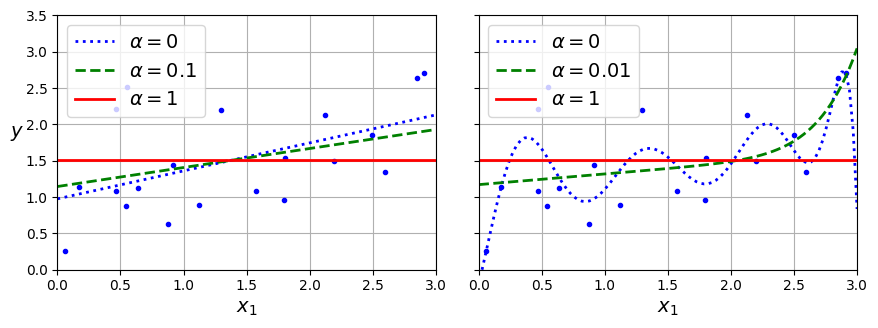

In [ ]:
plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
save_fig("lasso_regression_plot")
plt.show()

Os Gráficos abaixo, mostram o mapa do erro do modelo em função dos coeficientes $\theta_1$ e $\theta_2$.

As área coloridas, representam o erro, quanto maior o erro, mais clara a cor. O centro, é onde está a menor taxa de erro para o modelo.

A linha branca, representa o Gradiente Descendente calculado, até atingir o mínimo de erro.
- Importante observar que o cálculo do Gradiente foi inicializado com valores de $\theta_1$ e $\theta_2$ em 0.5 e 2.0 respectivamente.

Podemos observar a diferença no comportamento do cálculo, para atingir o valor mínimo de erro no treinamento do modelo.

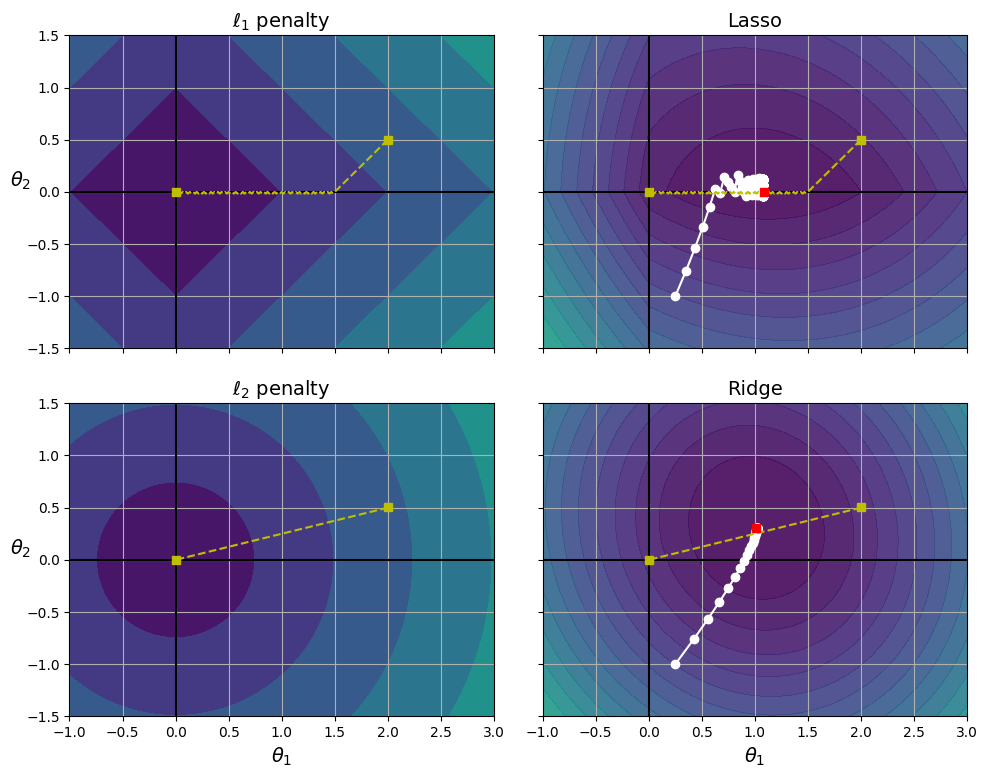

In [ ]:
t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

save_fig("lasso_vs_ridge_plot")
plt.show()

## Elastic Net

Elastic Net é uma regularização que combina Lasso (L1) e Ridge (L2), equilibrando “zerar coeficientes” e “reduzir coeficientes”.

Ele existe para resolver um problema do Lasso:
 - Quando as features são correlacionadas, o Lasso escolhe uma e descarta as outras arbitrariamente.


### IMPORTÂNCIA DA REGULARIZAÇÃO

Em uma Regressão Linear Simples, existe a possibilidade de overfitting do modelo aos dados, então sempre é preferível ter alguma regularização.

A Regressão Ridge (L2), é um bom padrão, mas se houver a suspeita de que apenas algumas das características são realmente úteis ao modelo, deve-se utilizar a Regressão Lasso (L1) ou Elastic Net devem ser utilizadas. Lembrando que a Elastic Net, tem a vantagem de em seu algoritmo "Reduzir Coeficientes", assim como ocorre na Regressão Ridge (L2).

Resumindo:
 - Lasso → escolhe uma feature
 - Ridge → usa todas, mas pequenas
 - Elastic Net → usa várias, de forma equilibrada

In [ ]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

### FIM DA 4ª DA DEMONSTRAÇÃO - voltar aos slides

# Avaliação do Modelo

### Calculando o MSE do modelo

In [ ]:
from sklearn.metrics import mean_squared_error

y_Predictions = elastic_net.predict(X)

lin_rmse = mean_squared_error(y, y_Predictions)
lin_rmse

0.3498832475934753

### Calculando o RMSE do modelo

**Aviso**: Em versões mais recentes do Scikit-Learn, você deve usar `root_mean_squared_error(labels, predictions)` para calcular o RMSE, em vez de `mean_squared_error(labels, predictions, squared=False)`.
O bloco `try`/`except` a seguir tenta importar `root_mean_squared_error` e, caso isso falhe, simplesmente define essa função.

In [ ]:
try:
  from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

y_Predictions = elastic_net.predict(X)

lin_rmse = root_mean_squared_error(y, y_Predictions)
lin_rmse

0.5915092962866055

## Parada Antecipada

**Parada antecipada** é uma técnica para evitar overfitting em modelos treinados de forma iterativa.

A ideia é parar de treinar o modelo, quando este começa a aprender demais o treino e piora na sua validação.


Importante lembrar que a classe `SGDClassifier` do Scikit Learn, que utiliza Gradiente Descendente Estocástico / Mini Batches, também implementa Parada Antecipada internamente, que terá seu comportamento definido pelos parâmetros `early_stopping`, `n_iter_no_change` e `tol`.


**Exemplo de Implementação de Parada Antecipada**

Vamos voltar ao conjunto de dados quadrático que usamos anteriormente:

**Aviso**: nas versões mais recentes do Scikit-Learn, você deve usar `root_mean_squared_error()` para calcular o RMSE, em vez de `mean_squared_error(labels, predictions, squared=False)`.  
O bloco `try`/`except` a seguir tenta importar `root_mean_squared_error` e, se falhar, simplesmente o define.

In [ ]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

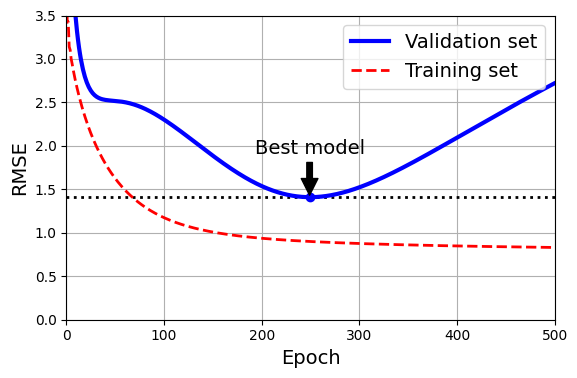

In [ ]:
from copy import deepcopy
from sklearn.preprocessing import StandardScaler

#Cria o mesmo dataset anterior e o divide
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []

# Avaliando o Modelo
for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)

    # Aqui podemos fazer a lógica para que o modelo pare de ser treinado, ao encontrar o melhor RMSE
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # Avaliamos o erro de treino e o salvamos para a figura
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    val_errors.append(val_error)
    train_errors.append(train_error)

# Gerando o Gráfico
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()
save_fig("early_stopping_plot")
plt.show()

# Exercícios

1. Gere um novo conjunto de dados com 200 amostras

In [ ]:
# RESOLUÇÃO EXERCÍCIO 1

2. Utilize a Equação Normal para encontrar os parâmetros

In [ ]:
# RESOLUÇÃO EXERCÍCIO 2

3. Compare os coeficientes com o resultado do LinearRegression do Scikit-Learn

In [ ]:
# RESOLUÇÃO EXERCÍCIO 3

***Reflexão*** → Os valores encontrados são iguais? Por quê?

4. Implemente o Gradiente Descendente

In [ ]:
# RESOLUÇÃO EXERCÍCIO 4

5. Teste três valores de α:
 - 0.001
 - 0.1
 - 0.5

In [ ]:
# RESOLUÇÃO EXERCÍCIO 5

***Reflexão*** → Observe o comportamento da convergência
 - O que acontece quando α é muito pequeno?
 - O que acontece quando α é muito grande?

**Como você identificar convergência?**

6 . Gere dados não lineares

In [ ]:
# RESOLUÇÃO EXERCÍCIO 6

7 Ajuste modelos com grau:
 - 1
 - 2
 - 20

In [ ]:
# RESOLUÇÃO EXERCÍCIO 7

***Reflexão*** → Qual modelo parece melhor?
- Qual modelo apresenta overfitting?
- Como você identificou isso?

8. Ajuste um modelo polinomial de grau 10

In [ ]:
# RESOLUÇÃO EXERCÍCIO 8

9. Implemente modelos
 - Sem Regularização
 - Regularizado com Ridge (L2)
 - Regularizado com Lasso (L1)

 *Avalie*
 - O que acontece com os coeficientes em cada modelo?
 - Qual modelo parece mais estável?
 - Algum coeficiente foi zerado em algum modelo?

In [ ]:
# RESOLUÇÃO EXERCÍCIO 9

10. Implemente uma solução de Parada Antecipada

In [ ]:
# RESOLUÇÃO EXERCÍCIO 10

***Reflexão*** → Em alguma das resoluções, você chegou a precisar observar, ou pesquisar na documentação do Scikit Learn? Chegou a observar se no Scikit Learn tem alguma implementação dos algoritmos dos exercícios que poderia facilitar o seu trabalho?